In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy
from modules import gendata, SI_SeqFS_DA


Generate data

In [2]:
ns = 20
nt = 10
truebeta= [0, 0, 0]
p = len(truebeta)
print('true beta:', truebeta)

true_beta_s = np.full((p,1), 2) #source's beta
true_beta_t = np.array(truebeta).reshape((-1,1)) #target's beta

K = 2 # select k features
# generate data
Xs, Xt, Ys, Yt, Sigma_s, Sigma_t = gendata.generate(ns, nt, p, true_beta_s, true_beta_t)

true beta: [0, 0, 0]


### SI-SeqFS-DA with Forward Selection

In [ ]:

list_p_value = []
alpha = 0.05  
rejected = 0
detected = 0

max_iteration = 200
iter = range(max_iteration)

list_p_value = []
for i in iter:
    # generate data

    Xs, Xt, Ys, Yt, Sigma_s, Sigma_t = gendata.generate(ns, nt, p, true_beta_s, true_beta_t)
    pvalue = SI_SeqFS_DA.SI_SeqFS_DA(Xs, Ys, Xt, Yt, K, Sigma_s, Sigma_t, method='forward', jth = None)
    list_p_value.append(pvalue)
    print(f"Iteration {i+1}/{max_iteration}, p-value: {pvalue}")

for i in list_p_value:
    if i <= alpha:
        rejected += 1
    else:
        detected += 1
FPR = rejected / (rejected + detected)


Iteration 1/200, p-value: 0.7534857756378143
Iteration 2/200, p-value: 0.039519846832645866
Iteration 3/200, p-value: 0.7347848866637707
Iteration 4/200, p-value: 0.29560227929940547
Iteration 5/200, p-value: 0.9312175342776348
Iteration 6/200, p-value: 0.6763098155084852
Iteration 7/200, p-value: 0.42266403756890436
Iteration 8/200, p-value: 0.7782443210099715
Iteration 9/200, p-value: 0.46071432346421926
Iteration 10/200, p-value: 0.8443224148015204
Iteration 11/200, p-value: 0.2684942049370768
Iteration 12/200, p-value: 0.0925743386104064
Iteration 13/200, p-value: 0.7129372673997822
Iteration 14/200, p-value: 0.46736456674324645
Iteration 15/200, p-value: 0.06378561848436104
Iteration 16/200, p-value: 0.5149083233345472
Iteration 17/200, p-value: 0.4225911968005416
Iteration 18/200, p-value: 0.5532471408002946
Iteration 19/200, p-value: 0.27188873333848673
Iteration 20/200, p-value: 0.6324093653727696
Iteration 21/200, p-value: 0.49009339992184975
Iteration 22/200, p-value: 0.45468

False positive rate: 0.035
Uniform check (KS-Test result): 0.8033447620034909


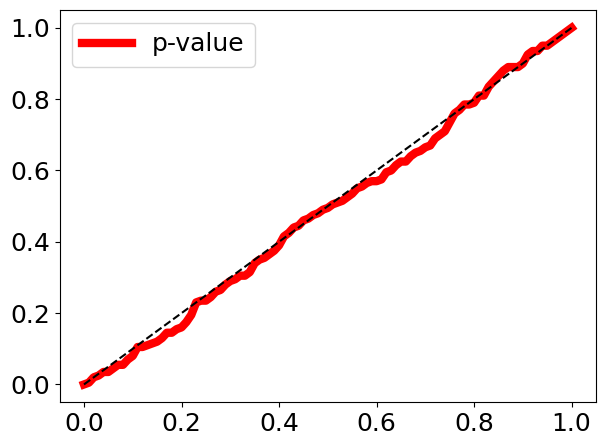

In [4]:
kstest = scipy.stats.kstest(list_p_value, 'uniform')
print(f"False positive rate: {FPR}")
print(f'Uniform check (KS-Test result): {kstest.pvalue}')

plt.rcParams.update({'font.size': 18})
grid = np.linspace(0, 1, 101)
plt.plot(grid, sm.distributions.ECDF(np.array(list_p_value))(grid), 'r-', linewidth=6, label='p-value')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.tight_layout()
plt.show()

### SI-SeqFS-DA with Backward Selection

In [5]:

list_p_value = []
alpha = 0.05  
rejected = 0
detected = 0

max_iteration = 200
iter = range(max_iteration)

list_p_value = []
for i in iter:
    # generate data
    Xs, Xt, Ys, Yt, Sigma_s, Sigma_t = gendata.generate(ns, nt, p, true_beta_s, true_beta_t)
    pvalue = SI_SeqFS_DA.SI_SeqFS_DA(Xs, Ys, Xt, Yt, K, Sigma_s, Sigma_t, method='backward', jth = None)
    list_p_value.append(pvalue)
    print(f"Iteration {i+1}/{max_iteration}, p-value: {pvalue}")

for i in list_p_value:
    if i <= alpha:
        rejected += 1
    else:
        detected += 1
FPR = rejected / (rejected + detected)


Iteration 1/200, p-value: 0.6389419753333292
Iteration 2/200, p-value: 0.29991260941063413
Iteration 3/200, p-value: 0.48642794250288124
Iteration 4/200, p-value: 0.2891830732533174
Iteration 5/200, p-value: 0.9795855121267454
Iteration 6/200, p-value: 0.09258084059448479
Iteration 7/200, p-value: 0.049360671061558836
Iteration 8/200, p-value: 0.4190227384468704
Iteration 9/200, p-value: 0.830467485686103
Iteration 10/200, p-value: 0.2709627506475004
Iteration 11/200, p-value: 0.5401072372794284
Iteration 12/200, p-value: 0.5572877026017531
Iteration 13/200, p-value: 0.5324349513691774
Iteration 14/200, p-value: 0.9354855469104468
Iteration 15/200, p-value: 0.07909951174956714
Iteration 16/200, p-value: 0.68829739548424
Iteration 17/200, p-value: 0.32240028149298605
Iteration 18/200, p-value: 0.5707552543534564
Iteration 19/200, p-value: 0.6172850775922986
Iteration 20/200, p-value: 0.9277674372081548
Iteration 21/200, p-value: 0.7672220834265515
Iteration 22/200, p-value: 0.3010284360

False positive rate: 0.06
Uniform check (KS-Test result): 0.4386809862999759


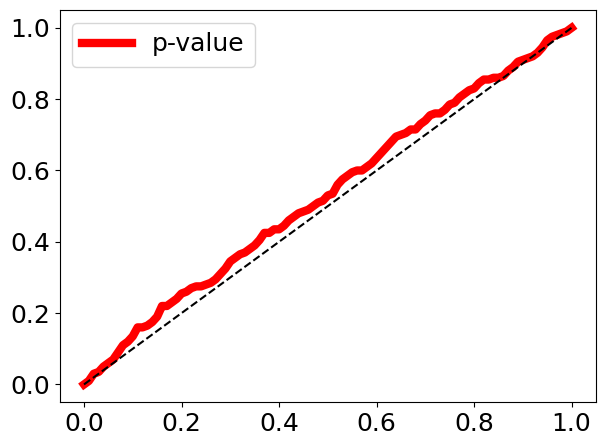

In [6]:
kstest = scipy.stats.kstest(list_p_value, 'uniform')
print(f"False positive rate: {FPR}")
print(f'Uniform check (KS-Test result): {kstest.pvalue}')

plt.rcParams.update({'font.size': 18})
grid = np.linspace(0, 1, 101)
plt.plot(grid, sm.distributions.ECDF(np.array(list_p_value))(grid), 'r-', linewidth=6, label='p-value')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.tight_layout()
plt.show()